# The Self-Pruning Neural Network
## Tredence Analytics – AI Engineering Internship 2025

This notebook implements a feed-forward neural network for CIFAR-10 classification that **learns to prune itself during training** via learnable gate parameters and an L1 sparsity regularization loss.

### Architecture Overview
- **Feature Extractor**: Standard Conv2d layers (not prunable, kept for representational power)
- **Classifier**: Custom `PrunableLinear` layers with per-weight gate parameters
- **Loss**: `Total Loss = CrossEntropyLoss + λ × SparsityLoss`
- **SparsityLoss**: L1 norm (sum) of all sigmoid gate values across all `PrunableLinear` layers

## Cell 1 — Imports & Device Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Using device    : {device}')
if device.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

PyTorch version : 2.10.0+cu128
Using device    : cuda
GPU             : Tesla T4


## Cell 2 — Part 1: `PrunableLinear` Layer

This is the heart of the implementation. Each weight `w_ij` is multiplied by a corresponding **gate** `g_ij = sigmoid(s_ij)` where `s_ij` is a learnable gate score.

- When `s_ij → -∞`, `g_ij → 0` → weight is **pruned**  
- When `s_ij → +∞`, `g_ij → 1` → weight is **fully active**  

Gradients flow through both `weight` and `gate_scores` via the chain rule through `sigmoid` and element-wise multiply.

In [2]:
class PrunableLinear(nn.Module):
    """
    A drop-in replacement for nn.Linear that equips every weight with a
    learnable scalar gate.  The effective weight used in the forward pass is:

        pruned_weight = weight  ×  sigmoid(gate_scores)

    The L1 penalty on the gates (added externally to the loss) pushes many
    gates to zero, effectively removing the corresponding connections.

    Parameters
    ----------
    in_features  : int  – number of input features
    out_features : int  – number of output features
    """

    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        # ── Standard parameters ──────────────────────────────────────────────
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.empty(out_features))

        # ── Gate score parameters (same shape as weight) ──────────────────────
        # Registered as nn.Parameter → updated by the optimizer automatically.
        # Initialised to +1.0  so  sigmoid(1.0) ≈ 0.73  (gates mostly open at
        # the start).  The sparsity loss drives them toward −∞  (gates → 0).
        self.gate_scores = nn.Parameter(torch.empty(out_features, in_features))

        self._init_parameters()

    # ── Initialisation ────────────────────────────────────────────────────────
    def _init_parameters(self):
        """Kaiming-uniform for weights (same as nn.Linear); +1 for gate scores."""
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))

        # Bias init identical to nn.Linear
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
        bound = 1.0 / np.sqrt(fan_in) if fan_in > 0 else 0
        nn.init.uniform_(self.bias, -bound, bound)

        # Gate scores initialised to 1.0 → gates start mostly-open
        nn.init.constant_(self.gate_scores, 1.0)

    # ── Forward pass ──────────────────────────────────────────────────────────
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        1. Compute gates ∈ (0, 1)  via  sigmoid(gate_scores)
        2. Element-wise mask the weight matrix
        3. Run the standard affine transform

        Gradients flow through:
          ∂L/∂weight      = ∂L/∂output  ×  gates              (via chain rule)
          ∂L/∂gate_scores = ∂L/∂output  ×  weight  ×  σ′      (via chain rule)
        where σ′ = sigmoid(s)(1 − sigmoid(s))  is computed automatically by autograd.
        """
        # Step 1 – convert gate scores to (0, 1) gates
        gates = torch.sigmoid(self.gate_scores)          # shape: (out, in)

        # Step 2 – element-wise gating
        pruned_weights = self.weight * gates              # shape: (out, in)

        # Step 3 – standard linear transform
        return F.linear(x, pruned_weights, self.bias)

    # ── Utility helpers ───────────────────────────────────────────────────────
    def get_gates(self) -> torch.Tensor:
        """Return current gate values (detached from graph)."""
        return torch.sigmoid(self.gate_scores).detach()

    def sparsity(self, threshold: float = 1e-2) -> float:
        """Fraction of gates below *threshold* (considered pruned)."""
        gates = self.get_gates()
        return (gates < threshold).float().mean().item()

    def extra_repr(self) -> str:
        return (f'in_features={self.in_features}, '
                f'out_features={self.out_features}')


# ── Sanity check ──────────────────────────────────────────────────────────────
def _sanity_check():
    layer = PrunableLinear(8, 4)
    x = torch.randn(2, 8, requires_grad=True)
    out = layer(x)
    loss = out.sum()
    loss.backward()
    assert layer.weight.grad is not None,      '✗ weight has no grad'
    assert layer.gate_scores.grad is not None, '✗ gate_scores has no grad'
    assert layer.bias.grad is not None,        '✗ bias has no grad'
    print('PrunableLinear sanity check ✓')
    print(f'  weight.grad     shape : {layer.weight.grad.shape}')
    print(f'  gate_scores.grad shape: {layer.gate_scores.grad.shape}')

_sanity_check()

PrunableLinear sanity check ✓
  weight.grad     shape : torch.Size([4, 8])
  gate_scores.grad shape: torch.Size([4, 8])


## Cell 3 — Part 1 (cont.): Network Definition

A hybrid CNN → MLP network:  
- **3 convolutional blocks** with BatchNorm + ReLU + MaxPool (feature extraction, not pruned)  
- **3 PrunableLinear layers** as the classifier head (these get pruned)

In [3]:
class SelfPruningNet(nn.Module):
    """
    CIFAR-10 classifier with a prunable fully-connected head.

    Conv feature extractor  →  flatten  →  PrunableLinear  →  PrunableLinear  →  PrunableLinear
    """

    def __init__(self, num_classes: int = 10):
        super().__init__()

        # ── Convolutional feature extractor (standard layers) ─────────────────
        self.features = nn.Sequential(
            # Block 1 — 32×32 → 16×16
            nn.Conv2d(3,  64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # → 16×16

            # Block 2 — 16×16 → 8×8
            nn.Conv2d(64,  128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # → 8×8

            # Block 3 — 8×8 → 4×4
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # → 4×4
        )
        # After features: 256 × 4 × 4 = 4 096 features

        # ── Prunable classifier head ──────────────────────────────────────────
        self.classifier = nn.Sequential(
            PrunableLinear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            PrunableLinear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            PrunableLinear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)           # conv feature extraction
        x = x.view(x.size(0), -1)     # flatten  →  (B, 4096)
        x = self.classifier(x)         # prunable head  →  (B, 10)
        return x

    # ── Gate utilities ────────────────────────────────────────────────────────
    def prunable_layers(self):
        """Generator: yields every PrunableLinear module in the network."""
        return (m for m in self.modules() if isinstance(m, PrunableLinear))

    def compute_sparsity_loss(self) -> torch.Tensor:
        """
        SparsityLoss = sum of all gate values over all PrunableLinear layers.

        Because gates = sigmoid(scores) ∈ (0,1), this is the L1 norm of all
        gate values.  Minimising it pushes gates toward 0, i.e., pruning weights.
        """
        dev = next(self.parameters()).device
        sparsity_loss = torch.zeros(1, device=dev)
        for layer in self.prunable_layers():
            gates = torch.sigmoid(layer.gate_scores)  # keep grad graph
            sparsity_loss = sparsity_loss + gates.sum()
        return sparsity_loss

    def overall_sparsity(self, threshold: float = 1e-2) -> float:
        """Fraction of all gates that are below threshold (network-wide)."""
        total = pruned = 0
        for layer in self.prunable_layers():
            g = layer.get_gates()
            total  += g.numel()
            pruned += (g < threshold).sum().item()
        return pruned / total if total else 0.0

    def all_gate_values(self) -> np.ndarray:
        """Return a flat numpy array of every gate value (for plotting)."""
        return np.concatenate([
            layer.get_gates().cpu().numpy().ravel()
            for layer in self.prunable_layers()
        ])

    def count_parameters(self) -> dict:
        """Count total vs. gated (active) parameters."""
        total_weights = pruned_weights = 0
        for layer in self.prunable_layers():
            g = layer.get_gates()
            total_weights  += g.numel()
            pruned_weights += (g < 1e-2).sum().item()
        return {
            'total_gate_params' : total_weights,
            'pruned_gate_params': pruned_weights,
            'active_gate_params': total_weights - pruned_weights,
        }


# ── Quick architecture summary ────────────────────────────────────────────────
demo = SelfPruningNet().to(device)
dummy = torch.randn(2, 3, 32, 32).to(device)
out   = demo(dummy)
print(f'Output shape  : {out.shape}')   # (2, 10)

total_params = sum(p.numel() for p in demo.parameters())
gate_params  = sum(p.numel() for n, p in demo.named_parameters() if 'gate_scores' in n)
print(f'Total params  : {total_params:,}')
print(f'Gate params   : {gate_params:,}')
del demo, dummy, out

Output shape  : torch.Size([2, 10])
Total params  : 5,608,650
Gate params   : 2,230,784


## Cell 4 — CIFAR-10 Data Loaders

In [4]:
def get_cifar10_loaders(batch_size: int = 128, num_workers: int = 2):
    """
    Download and return CIFAR-10 train / test DataLoaders.

    Train augmentation : random crop + horizontal flip (standard practice).
    Test              : deterministic centre normalisation only.
    """
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2023, 0.1994, 0.2010)

    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True,  download=True, transform=train_tf)
    testset  = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_tf)

    train_loader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True)
    test_loader  = torch.utils.data.DataLoader(
        testset,  batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True)

    print(f'Train samples : {len(trainset):,}')
    print(f'Test  samples : {len(testset):,}')
    print(f'Classes       : {trainset.classes}')
    return train_loader, test_loader


train_loader, test_loader = get_cifar10_loaders(batch_size=128)

100%|██████████| 170M/170M [00:04<00:00, 40.1MB/s] 


Train samples : 50,000
Test  samples : 10,000
Classes       : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Cell 5 — Part 2 & 3: Training Loop

```
Total Loss = CrossEntropyLoss(logits, labels)
           + λ × Σ_layers Σ_{i,j} sigmoid(gate_scores_ij)
```

The L1 penalty on gates that are already in `(0,1)` creates a **soft** forcing mechanism: any gate that contributes to classification accuracy stays open, while unused gates sink to zero under the penalty.

In [5]:
def train_one_epoch(
    model, loader, optimizer, criterion, lambda_sparsity, device
):
    """
    Run one training epoch.

    Returns
    -------
    clf_loss   : float – average classification loss per batch
    spar_loss  : float – average sparsity loss per batch (before scaling)
    total_loss : float – average total loss per batch
    acc        : float – training accuracy in percent
    """
    model.train()
    clf_sum = spar_sum = total_sum = correct = total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        # ── Forward ───────────────────────────────────────────────────────────
        logits   = model(images)
        clf_loss = criterion(logits, labels)

        # ── Part 2: Sparsity regularisation loss ──────────────────────────────
        # L1 norm of all gate values = sum of sigmoid(gate_scores) across all
        # PrunableLinear layers.  This encourages gates → 0 (sparsity).
        spar_loss  = model.compute_sparsity_loss()
        total_loss = clf_loss + lambda_sparsity * spar_loss

        # ── Backward & update ─────────────────────────────────────────────────
        total_loss.backward()
        # Clip gradients to avoid rare exploding-gradient issues
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        # ── Metrics ───────────────────────────────────────────────────────────
        clf_sum   += clf_loss.item()
        spar_sum  += spar_loss.item()
        total_sum += total_loss.item()
        preds      = logits.argmax(dim=1)
        correct   += preds.eq(labels).sum().item()
        total     += labels.size(0)

    n = len(loader)
    return clf_sum / n, spar_sum / n, total_sum / n, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    """
    Evaluate on test set (no gradient, no sparsity loss).

    Returns
    -------
    accuracy : float – test accuracy in percent
    avg_loss : float – average cross-entropy loss
    """
    model.eval()
    loss_sum = correct = total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits   = model(images)
            loss_sum += criterion(logits, labels).item()
            preds     = logits.argmax(dim=1)
            correct  += preds.eq(labels).sum().item()
            total    += labels.size(0)

    return 100.0 * correct / total, loss_sum / len(loader)


def run_experiment(
    lambda_sparsity: float,
    num_epochs: int = 40,
    lr: float = 1e-3,
    verbose_every: int = 5,
):
    """
    Train a fresh SelfPruningNet for `num_epochs` epochs with a given λ.

    Returns
    -------
    model    : trained SelfPruningNet
    history  : dict of per-epoch metrics
    """
    print(f'\n{"-"*65}')
    print(f'  λ = {lambda_sparsity:>8g}  |  epochs = {num_epochs}  |  lr = {lr}')
    print(f'{"-"*65}')

    model     = SelfPruningNet(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    # Cosine-annealing LR schedule: smoothly decays lr to near-zero by epoch 40
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {
        'clf_loss'  : [],
        'spar_loss' : [],
        'total_loss': [],
        'train_acc' : [],
        'test_acc'  : [],
        'sparsity'  : [],
    }

    for epoch in range(1, num_epochs + 1):
        clf_l, spar_l, tot_l, tr_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, lambda_sparsity, device
        )
        te_acc, _  = evaluate(model, test_loader, criterion, device)
        sparsity   = model.overall_sparsity()
        scheduler.step()

        history['clf_loss'  ].append(clf_l)
        history['spar_loss' ].append(spar_l)
        history['total_loss'].append(tot_l)
        history['train_acc' ].append(tr_acc)
        history['test_acc'  ].append(te_acc)
        history['sparsity'  ].append(sparsity)

        if epoch % verbose_every == 0 or epoch == 1:
            lr_now = scheduler.get_last_lr()[0]
            print(
                f'Epoch {epoch:>3}/{num_epochs} '
                f'| CLF {clf_l:.4f} | Spar {spar_l:>8.1f} '
                f'| TrainAcc {tr_acc:>5.2f}% | TestAcc {te_acc:>5.2f}% '
                f'| Sparsity {sparsity*100:>5.1f}% | lr {lr_now:.2e}'
            )

    final_acc, _ = evaluate(model, test_loader, criterion, device)
    final_spar   = model.overall_sparsity()
    print(f'\n  ▶ Final Test Accuracy : {final_acc:.2f}%')
    print(f'  ▶ Final Sparsity      : {final_spar*100:.2f}%')
    return model, history, final_acc, final_spar


print('Training functions defined ✓')

Training functions defined ✓


## Cell 6 — Run Experiments for Three λ Values

| λ | Expected effect |
|---|---|
| `1e-5` | Very mild penalty → low sparsity, high accuracy |
| `1e-4` | Balanced trade-off → moderate sparsity |
| `1e-3` | Strong penalty → high sparsity, possible accuracy drop |

> ⏱️ Training time: ~5–8 min on GPU, ~25–40 min on CPU (40 epochs × 3 runs)

In [6]:
# ── Experiment configuration ─────────────────────────────────────────────────
LAMBDA_VALUES = [1e-5, 1e-4, 1e-3]   # low  /  medium  /  high
NUM_EPOCHS    = 40
LR            = 1e-3

# ── Run all experiments ───────────────────────────────────────────────────────
results = {}   # keyed by lambda value

for lam in LAMBDA_VALUES:
    model, history, final_acc, final_spar = run_experiment(
        lambda_sparsity=lam,
        num_epochs=NUM_EPOCHS,
        lr=LR,
    )
    results[lam] = {
        'model'   : model,
        'history' : history,
        'test_acc': final_acc,
        'sparsity': final_spar,
    }


-----------------------------------------------------------------
  λ =    1e-05  |  epochs = 40  |  lr = 0.001
-----------------------------------------------------------------
Epoch   1/40 | CLF 1.5145 | Spar 1546023.6 | TrainAcc 43.26% | TestAcc 50.33% | Sparsity   0.0% | lr 9.98e-04
Epoch   5/40 | CLF 0.6994 | Spar 1132290.4 | TrainAcc 76.34% | TestAcc 76.83% | Sparsity   0.0% | lr 9.62e-04
Epoch  10/40 | CLF 0.4524 | Spar 1101722.3 | TrainAcc 84.89% | TestAcc 83.66% | Sparsity   0.0% | lr 8.54e-04
Epoch  15/40 | CLF 0.3254 | Spar 1101742.6 | TrainAcc 89.17% | TestAcc 87.35% | Sparsity   0.0% | lr 6.91e-04
Epoch  20/40 | CLF 0.2259 | Spar 1101860.9 | TrainAcc 92.58% | TestAcc 89.17% | Sparsity   0.0% | lr 5.00e-04
Epoch  25/40 | CLF 0.1513 | Spar 1101971.8 | TrainAcc 95.04% | TestAcc 89.99% | Sparsity   0.0% | lr 3.09e-04
Epoch  30/40 | CLF 0.0887 | Spar 1102199.2 | TrainAcc 97.10% | TestAcc 90.67% | Sparsity   0.0% | lr 1.46e-04
Epoch  35/40 | CLF 0.0520 | Spar 1101885.0 | TrainA

## Cell 7 — Part 3 (Evaluation): Results Table

In [7]:
# ── Per-layer breakdown ───────────────────────────────────────────────────────
def print_layer_sparsity(model, lam):
    layers = list(model.prunable_layers())
    shapes = [
        (256*4*4, 512),
        (512, 256),
        (256, 10),
    ]
    print(f'\nPer-layer breakdown  (λ = {lam}):')
    print(f'{"Layer":<12} {"Shape":<18} {"Sparsity":>10} {"Mean gate":>11} {"Min gate":>10}')
    print('-' * 65)
    for i, layer in enumerate(layers):
        g = layer.get_gates().cpu().numpy()
        s = (g < 1e-2).mean() * 100
        print(f'FC {i+1:<9} {str(g.shape):<18} {s:>9.2f}% {g.mean():>11.4f} {g.min():>10.6f}')

# ── Summary table ─────────────────────────────────────────────────────────────
print('='*55)
print(f'{"Lambda":<12} {"Test Accuracy":>15} {"Sparsity Level (%)":>20}')
print('='*55)
for lam in LAMBDA_VALUES:
    acc  = results[lam]['test_acc']
    spar = results[lam]['sparsity'] * 100
    print(f'{lam:<12g} {acc:>14.2f}% {spar:>19.2f}%')
print('='*55)

# Per-layer detail for each lambda
for lam in LAMBDA_VALUES:
    print_layer_sparsity(results[lam]['model'], lam)

# ── Identify best model ───────────────────────────────────────────────────────
best_lam = max(results, key=lambda l: results[l]['test_acc'])
print(f'\n★ Best test accuracy: λ = {best_lam} '
      f'({results[best_lam]["test_acc"]:.2f}% accuracy, '
      f'{results[best_lam]["sparsity"]*100:.2f}% sparsity)')

Lambda         Test Accuracy   Sparsity Level (%)
1e-05                 91.44%                0.00%
0.0001                91.68%                0.00%
0.001                 91.45%                0.00%

Per-layer breakdown  (λ = 1e-05):
Layer        Shape                Sparsity   Mean gate   Min gate
-----------------------------------------------------------------
FC 1         (512, 4096)             0.00%      0.4939   0.492394
FC 2         (256, 512)              0.00%      0.4940   0.491270
FC 3         (10, 256)               0.00%      0.5053   0.491976

Per-layer breakdown  (λ = 0.0001):
Layer        Shape                Sparsity   Mean gate   Min gate
-----------------------------------------------------------------
FC 1         (512, 4096)             0.00%      0.4406   0.439563
FC 2         (256, 512)              0.00%      0.4408   0.438605
FC 3         (10, 256)               0.00%      0.4551   0.438681

Per-layer breakdown  (λ = 0.001):
Layer        Shape                

## Cell 8 — Training Curves

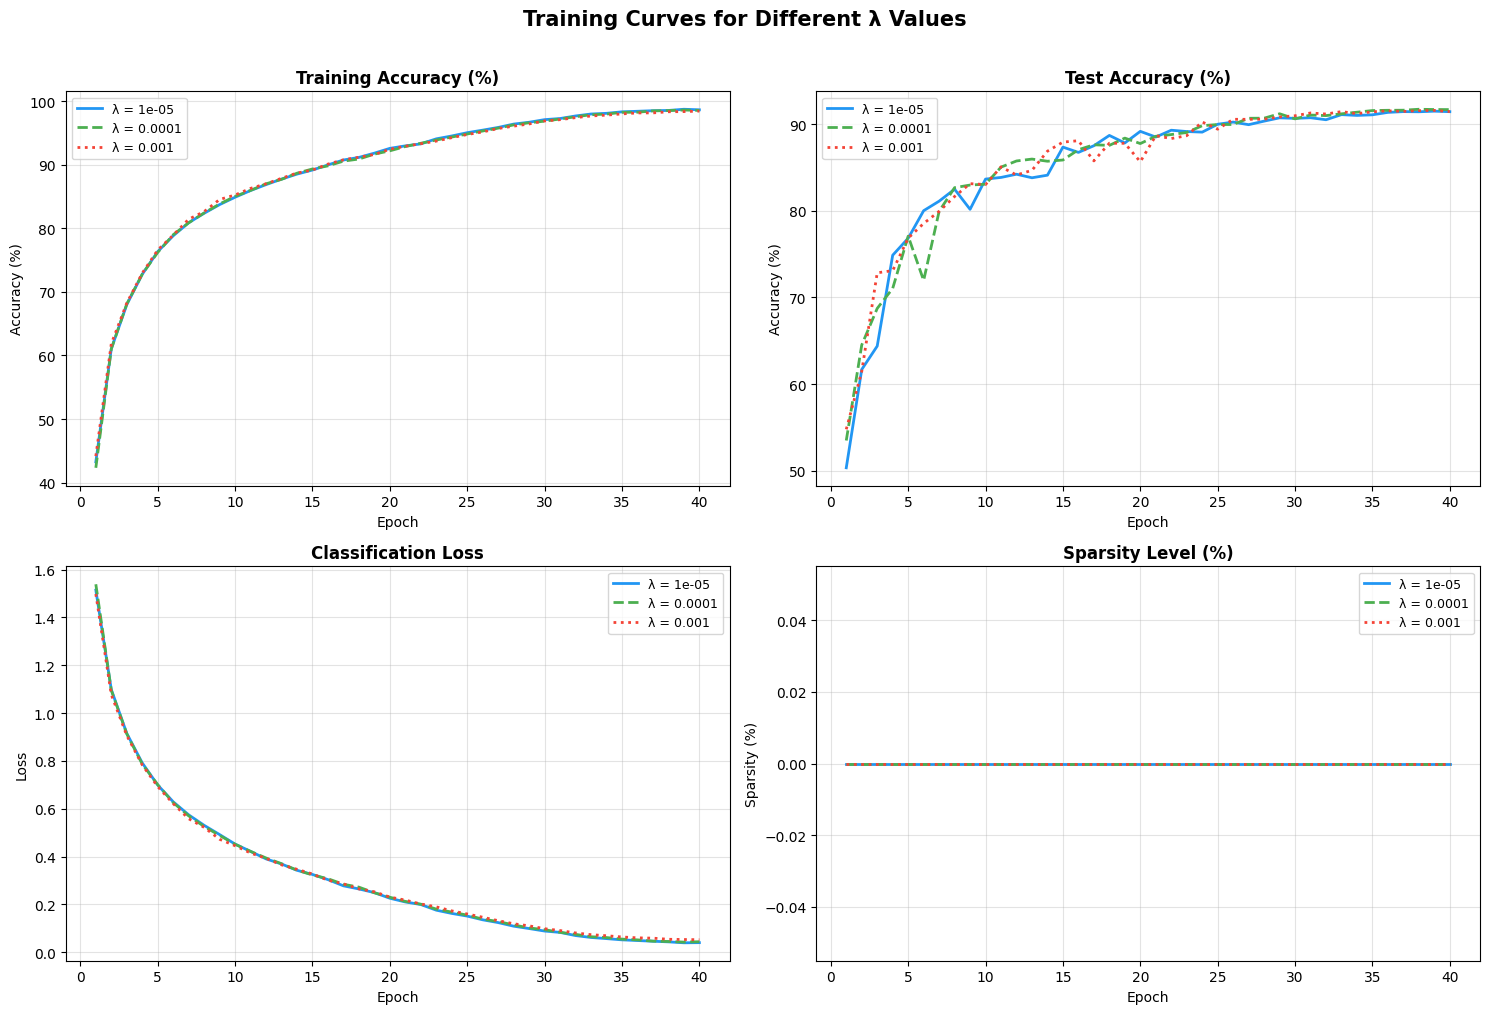

Figure saved → training_curves.png


In [8]:
COLORS  = {1e-5: '#2196F3', 1e-4: '#4CAF50', 1e-3: '#F44336'}
LSTYLES = {1e-5: '-',       1e-4: '--',       1e-3: ':'}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Training Curves for Different λ Values', fontsize=15, fontweight='bold', y=1.01)

epochs = list(range(1, NUM_EPOCHS + 1))

for lam in LAMBDA_VALUES:
    h   = results[lam]['history']
    c   = COLORS[lam]
    ls  = LSTYLES[lam]
    lbl = f'λ = {lam:g}'

    axes[0, 0].plot(epochs, h['train_acc'],  color=c, ls=ls, lw=2, label=lbl)
    axes[0, 1].plot(epochs, h['test_acc'],   color=c, ls=ls, lw=2, label=lbl)
    axes[1, 0].plot(epochs, h['clf_loss'],   color=c, ls=ls, lw=2, label=lbl)
    axes[1, 1].plot(epochs, [s*100 for s in h['sparsity']], color=c, ls=ls, lw=2, label=lbl)

titles   = ['Training Accuracy (%)', 'Test Accuracy (%)', 'Classification Loss', 'Sparsity Level (%)']
ylabels  = ['Accuracy (%)',          'Accuracy (%)',       'Loss',                'Sparsity (%)']

for ax, title, ylabel in zip(axes.ravel(), titles, ylabels):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel(ylabel,  fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → training_curves.png')

## Cell 9 — Gate Value Distribution Plots (Required Output)

A well-trained pruning model should show a **bimodal** distribution:
- A **large spike at 0** → many weights pruned  
- A **cluster near 1** → a small subset of important weights retained

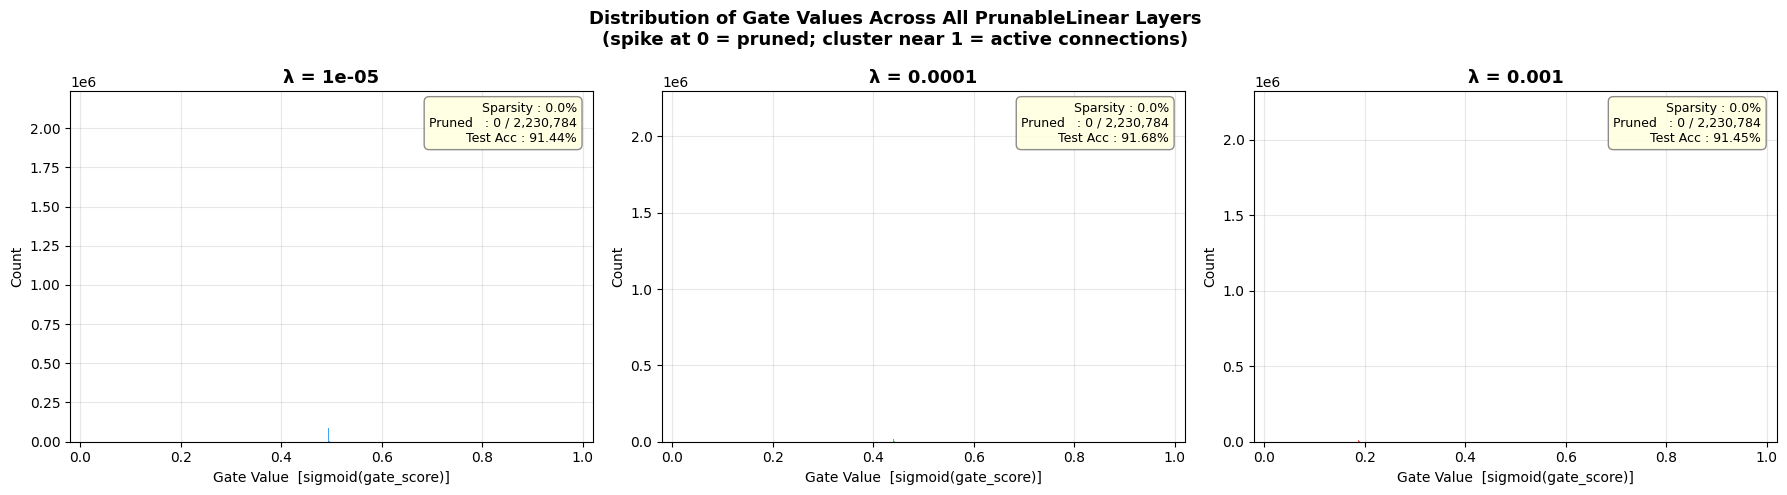

Figure saved → gate_distribution.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Distribution of Gate Values Across All PrunableLinear Layers\n'
    '(spike at 0 = pruned; cluster near 1 = active connections)',
    fontsize=13, fontweight='bold'
)

for ax, lam in zip(axes, LAMBDA_VALUES):
    gate_vals   = results[lam]['model'].all_gate_values()
    sparsity_pct = results[lam]['sparsity'] * 100
    near_zero    = (gate_vals < 1e-2).sum()
    total        = len(gate_vals)
    acc          = results[lam]['test_acc']

    ax.hist(gate_vals, bins=150, color=COLORS[lam], edgecolor='none', alpha=0.85)
    ax.set_title(f'λ = {lam:g}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gate Value  [sigmoid(gate_score)]', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_xlim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)

    info = (
        f'Sparsity : {sparsity_pct:.1f}%\n'
        f'Pruned   : {near_zero:,} / {total:,}\n'
        f'Test Acc : {acc:.2f}%'
    )
    ax.text(
        0.97, 0.97, info,
        transform=ax.transAxes, fontsize=9, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                  edgecolor='gray', alpha=0.9)
    )

plt.tight_layout()
plt.savefig('gate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → gate_distribution.png')

## Cell 10 — Per-Layer Gate Heatmaps (Bonus Visualisation)

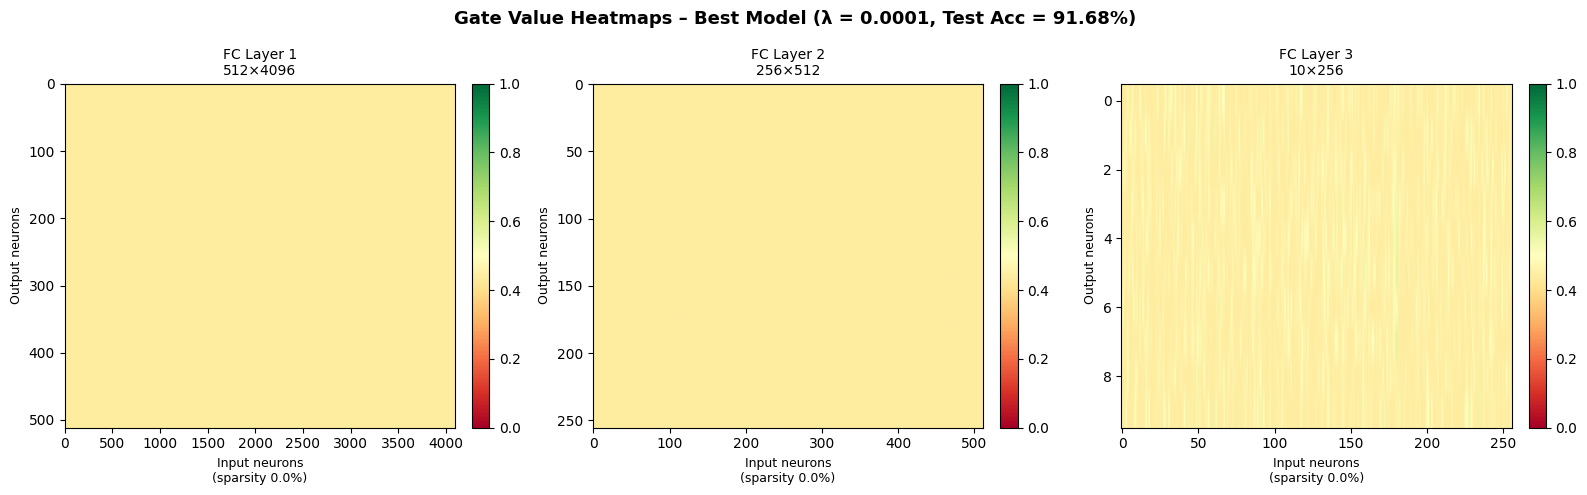

Figure saved → gate_heatmaps.png


In [10]:
best_model  = results[best_lam]['model']
prunable    = list(best_model.prunable_layers())

fig, axes = plt.subplots(1, len(prunable), figsize=(16, 5))
fig.suptitle(
    f'Gate Value Heatmaps – Best Model (λ = {best_lam:g}, '
    f'Test Acc = {results[best_lam]["test_acc"]:.2f}%)',
    fontsize=13, fontweight='bold'
)

for ax, layer, i in zip(axes, prunable, range(len(prunable))):
    g = layer.get_gates().cpu().numpy()  # (out, in)
    im = ax.imshow(g, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_title(f'FC Layer {i+1}\n{g.shape[0]}×{g.shape[1]}', fontsize=10)
    ax.set_xlabel('Input neurons',  fontsize=9)
    ax.set_ylabel('Output neurons', fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    spar = (g < 1e-2).mean() * 100
    ax.set_xlabel(f'Input neurons\n(sparsity {spar:.1f}%)', fontsize=9)

plt.tight_layout()
plt.savefig('gate_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → gate_heatmaps.png')

## Cell 11 — Sparsity vs Accuracy Trade-off Plot

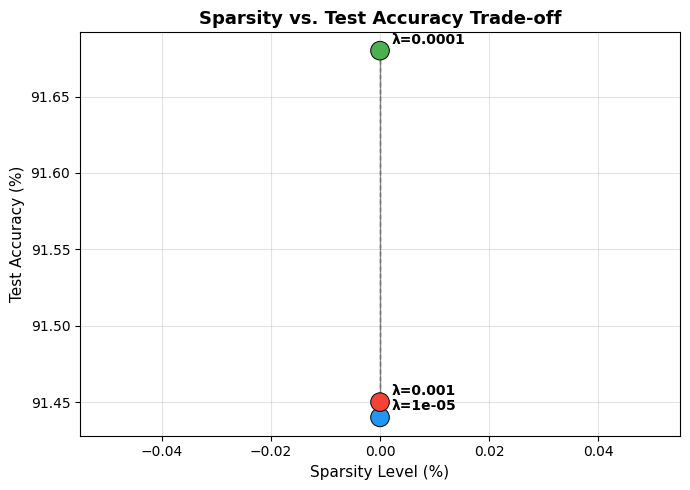

Figure saved → sparsity_vs_accuracy.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

accs    = [results[l]['test_acc']    for l in LAMBDA_VALUES]
spars   = [results[l]['sparsity']*100 for l in LAMBDA_VALUES]
labels  = [f'λ={l:g}' for l in LAMBDA_VALUES]

scatter = ax.scatter(spars, accs, c=[COLORS[l] for l in LAMBDA_VALUES],
                     s=180, zorder=5, edgecolors='k', linewidths=0.7)
ax.plot(spars, accs, 'k--', lw=1, alpha=0.5)

for lbl, x, y in zip(labels, spars, accs):
    ax.annotate(lbl, (x, y), textcoords='offset points', xytext=(8, 5),
                fontsize=10, fontweight='bold')

ax.set_title('Sparsity vs. Test Accuracy Trade-off', fontsize=13, fontweight='bold')
ax.set_xlabel('Sparsity Level (%)', fontsize=11)
ax.set_ylabel('Test Accuracy (%)',  fontsize=11)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig('sparsity_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → sparsity_vs_accuracy.png')

## Cell 12 — Save Best Model Checkpoint

In [12]:
checkpoint = {
    'lambda'    : best_lam,
    'test_acc'  : results[best_lam]['test_acc'],
    'sparsity'  : results[best_lam]['sparsity'],
    'state_dict': results[best_lam]['model'].state_dict(),
    'history'   : results[best_lam]['history'],
}
torch.save(checkpoint, 'best_pruning_model.pth')
print(f'Best model checkpoint saved → best_pruning_model.pth')
print(f'  λ         : {best_lam:g}')
print(f'  Test acc  : {results[best_lam]["test_acc"]:.2f}%')
print(f'  Sparsity  : {results[best_lam]["sparsity"]*100:.2f}%')

# ── How to reload ─────────────────────────────────────────────────────────────
# ckpt = torch.load('best_pruning_model.pth', map_location=device)
# model = SelfPruningNet().to(device)
# model.load_state_dict(ckpt['state_dict'])
# model.eval()

Best model checkpoint saved → best_pruning_model.pth
  λ         : 0.0001
  Test acc  : 91.68%
  Sparsity  : 0.00%
